# SQL Refresher 3

## imports

In [1]:
import math
import numpy as np
import pandas as pd

import psycopg2

import matplotlib.pyplot as plt
import seaborn as sns

## my_select_query_pandas() - function to run a select query and return rows in a Pandas dataframe

In [2]:
#
# function to run a select query and return rows in a pandas dataframe
# pandas puts all numeric values from postgres to float
# if it will fit in an integer, change it to integer
#

def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integers
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)
    

## Connect to the Postgres database

In [3]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)

## Create a cursor for the connection

In [4]:
cursor = connection.cursor()

# Lab: Basic Pie Charts, Grids of Subplots

## Find a list of products with the total quantity for each product

In [5]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select p.description as product,
       sum(l.quantity) as total_quantity_sold
from line_items as l
     join products as p
         on l.product_id = p.product_id
group by l.product_id, product
order by product

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,product,total_quantity_sold
0,Brocolli Stir Fry,913984
1,Chicken Salad,228561
2,Curry Chicken,1368884
3,Eggplant Lasagna,1599058
4,Pistachio Salmon,1828778
5,Spinach Orzo,456769
6,Teriyaki Chicken,1145013
7,Tilapia Piccata,687237


## A simple pie chart showing each meal's popularity 

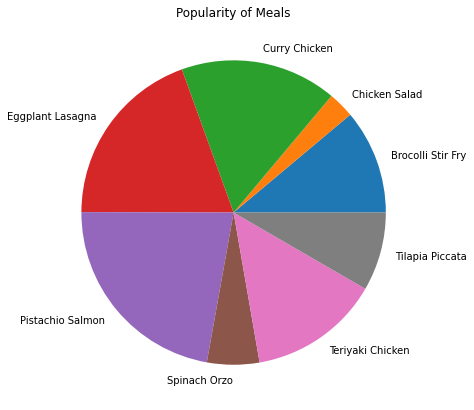

In [6]:
plt.figure(figsize=(7,7))
plt.pie(df['total_quantity_sold'], labels=df['product'])
plt.title('Popularity of Meals')
plt.show()

## Find products, day of week, and sales

In [7]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select p.description as product,
       extract(dow from sa.sale_date) as dow,
       to_char(sa.sale_date, 'Day') as day_of_week,
       sum(l.quantity) as total_quantity_sold
from sales as sa
     join line_items as l
         on sa.store_id = l.store_id and sa.sale_id = l.sale_id
     join products as p
         on l.product_id = p.product_id
group by product, dow, day_of_week
order by product, dow

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,product,dow,day_of_week,total_quantity_sold
0,Brocolli Stir Fry,0,Sunday,172250
1,Brocolli Stir Fry,1,Monday,121717
2,Brocolli Stir Fry,2,Tuesday,63474
3,Brocolli Stir Fry,3,Wednesday,128920
4,Brocolli Stir Fry,4,Thursday,128574
5,Brocolli Stir Fry,5,Friday,119356
6,Brocolli Stir Fry,6,Saturday,179693
7,Chicken Salad,0,Sunday,43110
8,Chicken Salad,1,Monday,30790
9,Chicken Salad,2,Tuesday,16165


## Postgres's version of pivot tables is called a crosstab;  create a crosstab to create a pivot table with product as the first column, followed by a column for each day of the week

In [8]:
rollback_before_flag = True
rollback_after_flag = True

# It's a pivot table
query = """

select *
from crosstab(
    '
        select product, day_of_week, total_quantity_sold
        from 
            (
            select p.description as product,
                   extract(dow from sa.sale_date) as dow,
                   to_char(sa.sale_date, ''Day'') as day_of_week,
                   sum(l.quantity) as total_quantity_sold
            from sales as sa
                join line_items as l
                     on sa.store_id = l.store_id and sa.sale_id = l.sale_id
                join products as p
                     on l.product_id = p.product_id
            group by product, dow, day_of_week
            order by product, dow
            ) as a
    ')
as ("product" varchar, "Sunday" numeric, "Monday" numeric, "Tuesday" numeric, 
        "Wednesday" numeric, "Thursday" numeric, "Friday" numeric, "Saturday" numeric)

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,product,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
0,Brocolli Stir Fry,172250,121717,63474,128920,128574,119356,179693
1,Chicken Salad,43110,30790,16165,32022,31882,29439,45153
2,Curry Chicken,257216,182341,95665,194197,191924,178281,269260
3,Eggplant Lasagna,301726,213187,111946,225751,223552,208591,314305
4,Pistachio Salmon,344315,244255,127559,257872,256310,238730,359737
5,Spinach Orzo,85968,61027,31870,64934,64369,59329,89272
6,Teriyaki Chicken,215741,152175,79962,161531,160195,149701,225708
7,Tilapia Piccata,128763,91818,47970,97486,96081,89792,135327


## A grid of subplots from the pivot table; each subplot will be a day of the week with a pie chart showing the percentage of sales for each meal for that day

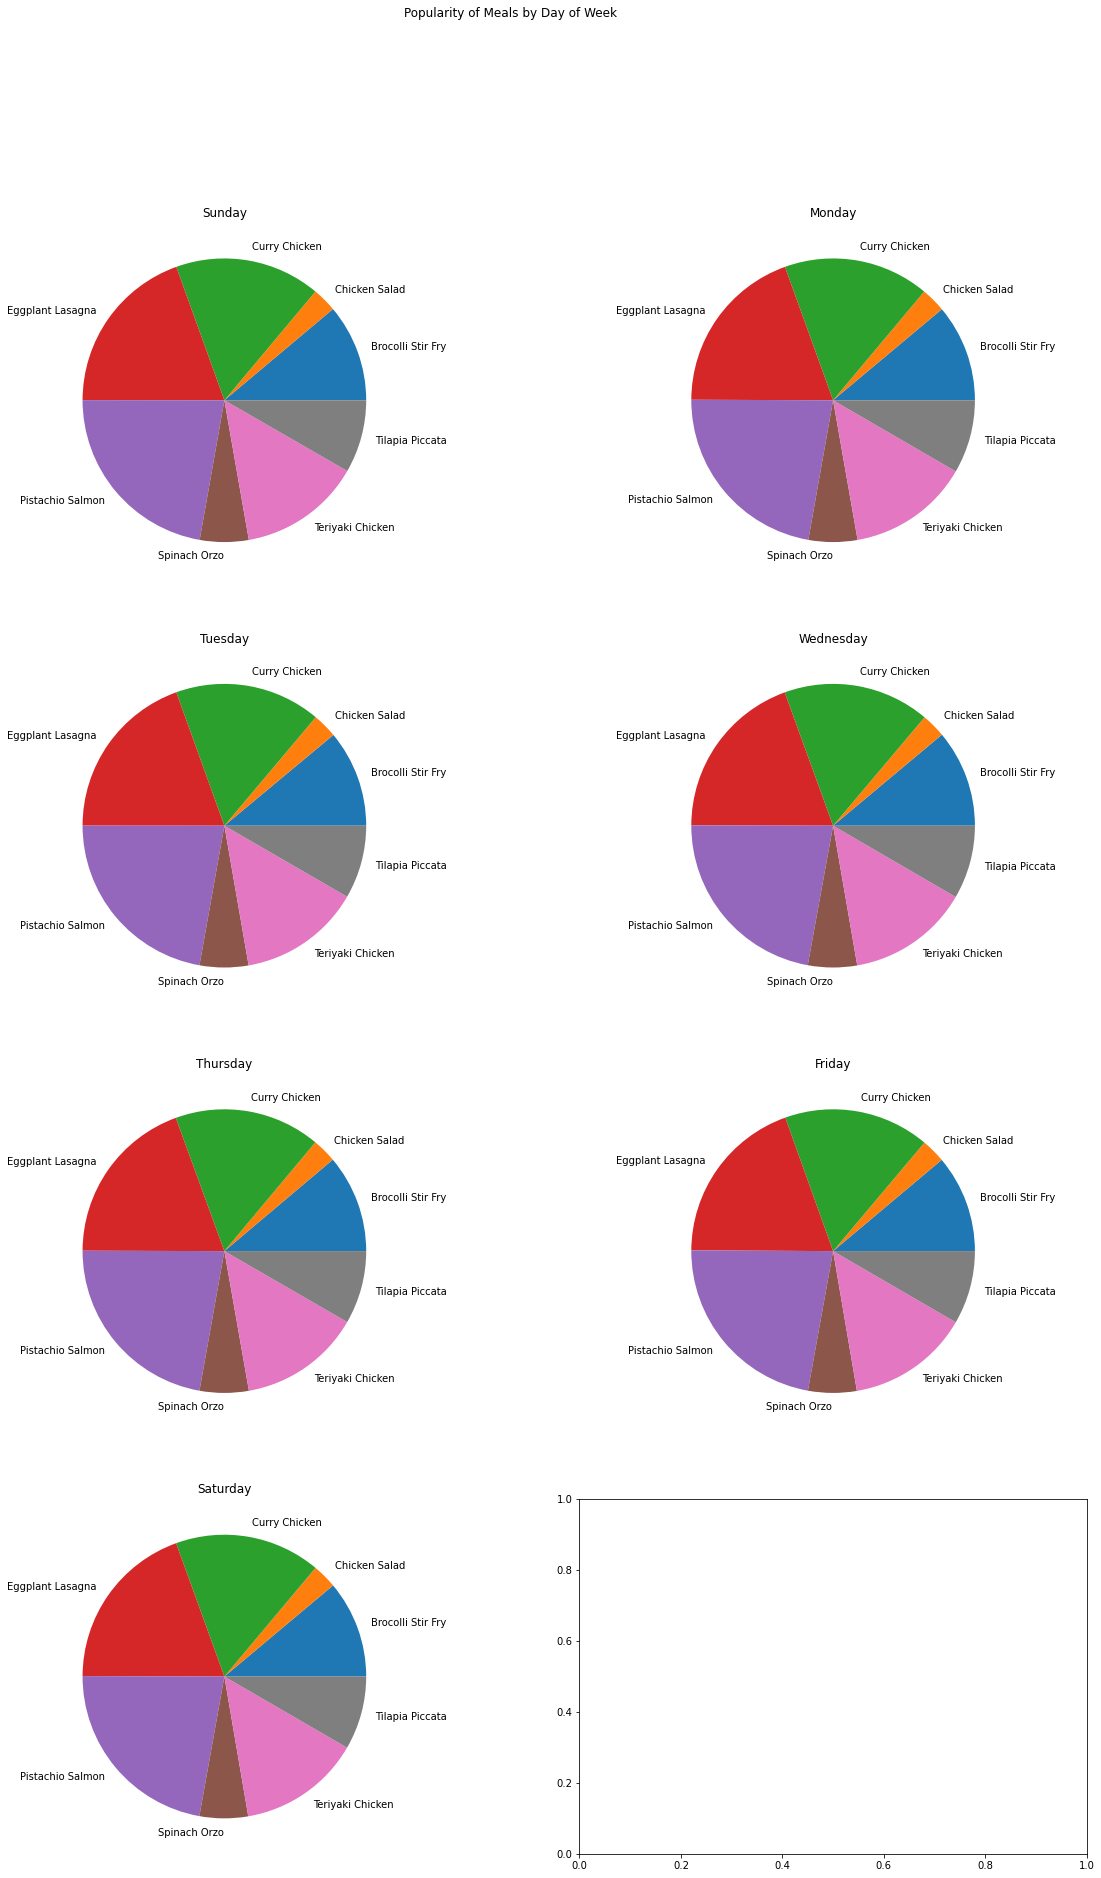

In [9]:
fig, ax = plt.subplots(4, 2, figsize=(20,30))
fig.suptitle('Popularity of Meals by Day of Week')

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

day_count = 0

for i in range(0,4):
    for j in range(0,2):
        if not (i == 3 and j == 1):
            ax[i][j].pie(df[days[day_count]], labels=df['product'])
            ax[i][j].set_title(days[day_count])
        day_count += 1


# Lab: Basic Scatter Plots, Line Plots

## For each sale, find the distance and quantity sold for product 1 (Pistachio Salmon)

In [10]:
rollback_before_flag = True
rollback_after_flag = True

# Does the customer who lives far buys more?
query = """

select cu.distance,
       l.quantity
from sales as sa
     join customers as cu
         on sa.customer_id = cu.customer_id
     join line_items as l
         on sa.store_id = l.store_id and sa.sale_id = l.sale_id
where l.product_id = 1
order by 1, 2

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,distance,quantity
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
1018980,25,6
1018981,25,6
1018982,25,6
1018983,25,6


## A simple scatter plot of quantity versus distance for product 1 (Pistachio Salmon)

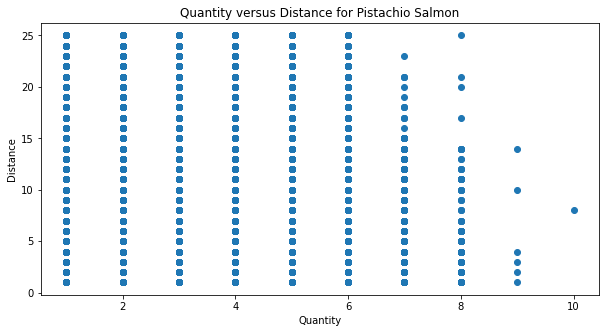

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(df['quantity'], df['distance'])
plt.title('Quantity versus Distance for Pistachio Salmon')
plt.xlabel('Quantity')
plt.ylabel('Distance')
plt.show()

## For each sale, find the distance and quantity sold for product 5 (Chicken Salad)

In [12]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select cu.distance,
       l.quantity
from sales as sa
     join customers as cu
         on sa.customer_id = cu.customer_id
     join line_items as l
         on sa.store_id = l.store_id and sa.sale_id = l.sale_id
where l.product_id = 5
order by 1, 2

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,distance,quantity
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
210314,25,2
210315,25,2
210316,25,2
210317,25,2


## A simple scatter plot of quantity versus distance for product 5 (Chicken Salad)

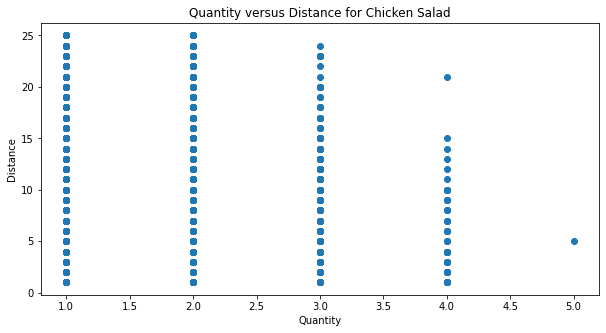

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(df['quantity'], df['distance'])
plt.title('Quantity versus Distance for Chicken Salad')
plt.xlabel('Quantity')
plt.ylabel('Distance')
plt.show()

## For each month, find total sales

In [14]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select extract(month from sa.sale_date) as month_number,
       to_char(sa.sale_date, 'Month') as month,
       round(sum(sa.total_amount) / 1000000,1) as total_sales
from sales as sa
group by month_number, month
order by month_number

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,month_number,month,total_sales
0,1,January,7.8
1,2,February,7.6
2,3,March,8.8
3,4,April,8.3
4,5,May,8.0
5,6,June,8.1
6,7,July,8.0
7,8,August,9.0
8,9,September,7.6
9,10,October,8.9


## Line plot for sales by month

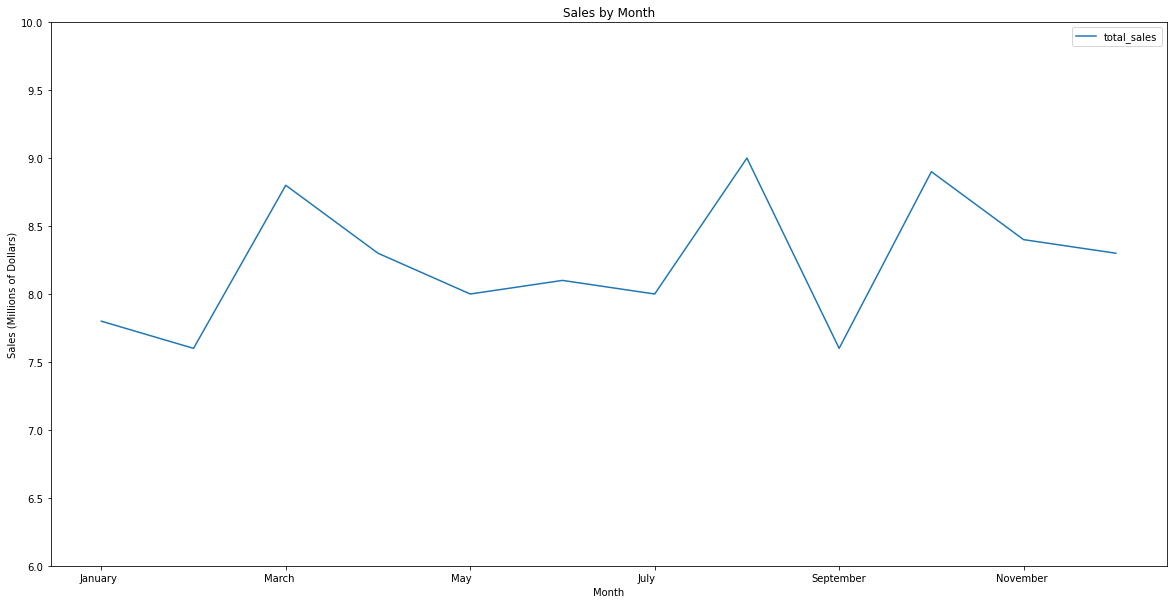

In [15]:
df.plot(x='month', y='total_sales', figsize=(20,10))
plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales (Millions of Dollars)')
plt.ylim(bottom=6, top=10)
plt.show()

# Lab: Basic Bar Charts, Histograms

## For each day of the week, find total sales

In [16]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select extract(dow from sa.sale_date) as dow,
       to_char(sa.sale_date, 'Day') as day_of_week,
       round(sum(sa.total_amount) / 1000000) as total_sales
from sales as sa
group by dow, day_of_week
order by dow

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,dow,day_of_week,total_sales
0,0,Sunday,19
1,1,Monday,13
2,2,Tuesday,7
3,3,Wednesday,14
4,4,Thursday,14
5,5,Friday,13
6,6,Saturday,19


## Bar chart of sales by day of week

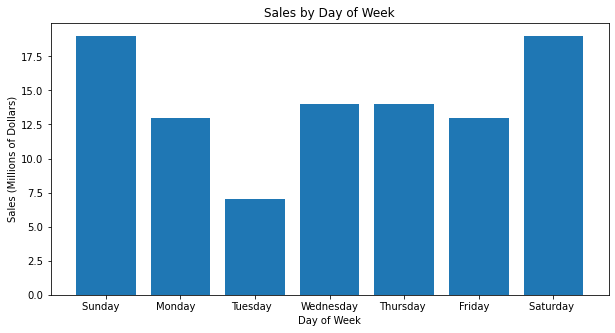

In [17]:
plt.figure(figsize=(10,5))
plt.bar(df['day_of_week'], df['total_sales'])
plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales (Millions of Dollars)')
plt.show()

## Horizontal Bar chart of sales by day of week

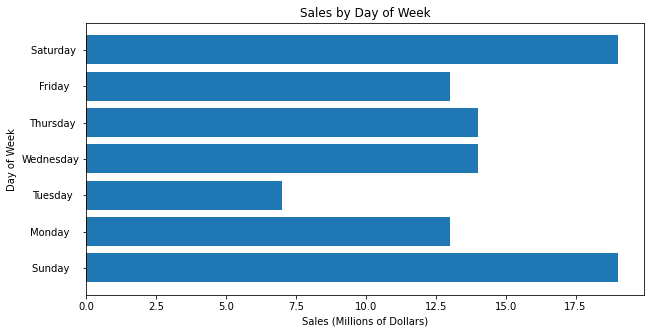

In [19]:
df = df.reindex(index=df.index[::-1])
plt.figure(figsize=(10,5))
plt.barh(df['day_of_week'], df['total_sales'])
plt.title('Sales by Day of Week')
plt.ylabel('Day of Week')
plt.xlabel('Sales (Millions of Dollars)')
plt.show()

## For each store and each day of the week, find total sales

In [20]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select s.city as store,
       extract(dow from sa.sale_date) as dow,
       to_char(sa.sale_date, 'Day') as day_of_week,
       sum(sa.total_amount) as total_sales
from stores as s
     join sales as sa
         on s.store_id = sa.store_id
group by store, dow, day_of_week
order by store, dow
"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,store,dow,day_of_week,total_sales
0,Berkeley,0,Sunday,4694640
1,Berkeley,1,Monday,3340116
2,Berkeley,2,Tuesday,1752036
3,Berkeley,3,Wednesday,3546144
4,Berkeley,4,Thursday,3507660
5,Berkeley,5,Friday,3273240
6,Berkeley,6,Saturday,4927224
7,Dallas,0,Sunday,3650748
8,Dallas,1,Monday,2602980
9,Dallas,2,Tuesday,1352760


## Create a pivot table (crosstab) with a column for store and a column for each day of the week

In [21]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from crosstab(
    '
        select store, day_of_week, total_sales
        from 
            (
            select s.city as store,
                   extract(dow from sa.sale_date) as dow,
                   to_char(sa.sale_date, ''Day'') as day_of_week,
                   round(sum(sa.total_amount) / 1000000, 1) as total_sales
            from stores as s
                 join sales as sa
                     on s.store_id = sa.store_id
            group by store, dow, day_of_week
            order by store, dow
            ) as a
    ')
as ("store" varchar, "Sunday" numeric, "Monday" numeric, "Tuesday" numeric, 
        "Wednesday" numeric, "Thursday" numeric, "Friday" numeric, "Saturday" numeric)

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,store,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
0,Berkeley,4.7,3.3,1.8,3.5,3.5,3.3,4.9
1,Dallas,3.7,2.6,1.4,2.7,2.7,2.5,3.8
2,Miami,3.3,2.4,1.2,2.5,2.5,2.3,3.5
3,Nashville,2.7,1.9,1.0,2.1,2.0,1.9,2.9
4,Seattle,4.2,2.9,1.5,3.1,3.1,2.9,4.3


## Bar chart with multiple bars showing sales by store by day of week

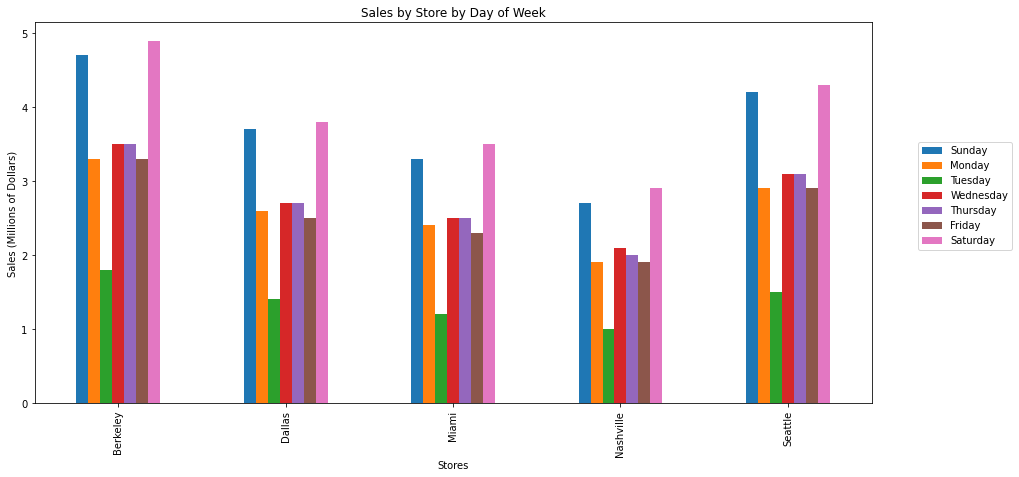

In [22]:
df.plot.bar(figsize=(15,7))

plt.title('Sales by Store by Day of Week')
plt.xlabel('Stores')
plt.ylabel('Sales (Millions of Dollars)')

plt.xticks(np.arange(5), labels=df['store'])
plt.legend(bbox_to_anchor=(1.05, 0.7))
plt.show()



## For each sale, find the quantity

In [23]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select round((sa.total_amount / 12)) as quantity_per_purchase
from sales as sa

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,quantity_per_purchase
0,4
1,11
2,4
3,8
4,3
...,...
1537612,5
1537613,8
1537614,5
1537615,1


## Histogram of quantity per purchase

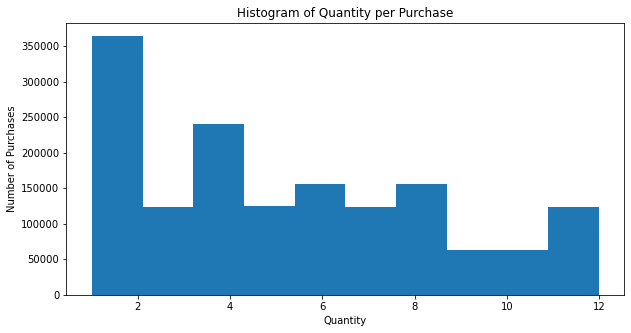

In [24]:
plt.figure(figsize=(10,5))
plt.hist(df['quantity_per_purchase'])
plt.title('Histogram of Quantity per Purchase')
plt.xlabel('Quantity')
plt.ylabel('Number of Purchases')
plt.show()


# Lab: Basic Box Plots, Violin Plots

## For each product, for each line item, find the quantity

In [25]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select p.description as product,
       l.quantity
from line_items as l
     join products as p
         on l.product_id = p.product_id
order by product

"""

df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
df

,product,quantity
0,Brocolli Stir Fry,1
1,Brocolli Stir Fry,1
2,Brocolli Stir Fry,1
3,Brocolli Stir Fry,1
4,Brocolli Stir Fry,1
...,...,...
5417969,Tilapia Piccata,1
5417970,Tilapia Piccata,1
5417971,Tilapia Piccata,1
5417972,Tilapia Piccata,1


## Box plot grouped by product of each line item quanity sold

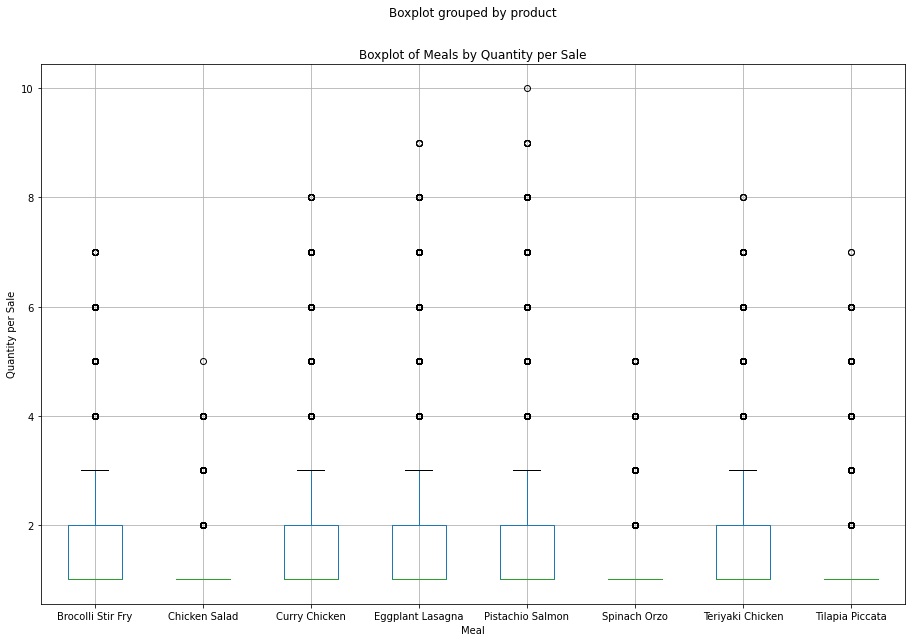

In [26]:
df.boxplot(by='product', column=['quantity'], figsize=(15,10))
plt.title('Boxplot of Meals by Quantity per Sale')
plt.xlabel('Meal')
plt.ylabel('Quantity per Sale')
plt.show()

## Violin plot grouped by product of each line item quanity sold

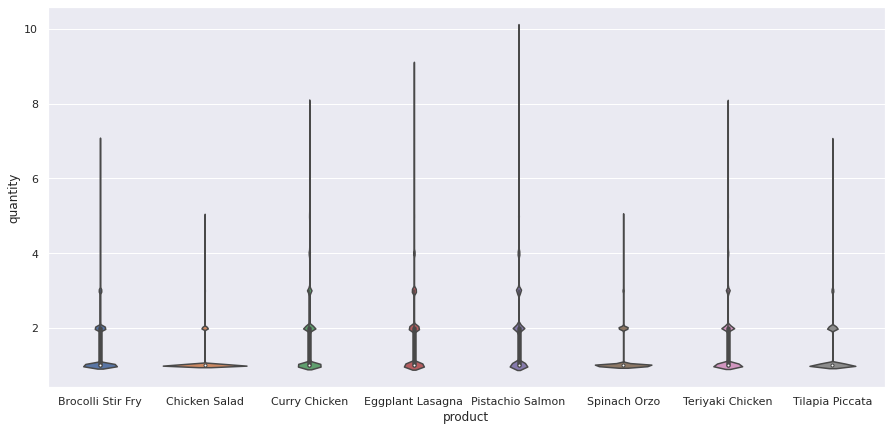

In [27]:
df['quantity'] = df['quantity'].astype(float)

sns.set(rc={'figure.figsize':(15,7)})

ax = sns.violinplot(x='product',y='quantity', data=df)